In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. LOAD DATA

In [10]:
df = pd.read_csv("data_fix.csv")
print("Số dòng:", len(df))
print("Các features:", df.columns.tolist())

Số dòng: 2336125
Các features: ['ts', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'symbol']


2. CHECK OUTLIERS BẰNG IQR CHO CÁC CỘT SỐ

In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns
iqr_info = {}

print("\n=== PHÂN TÍCH OUTLIERS THEO IQR ===")

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_pct = (len(outliers) / len(df)) * 100

    iqr_info[col] = {
        "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "Lower": lower, "Upper": upper,
        "Outliers": len(outliers), "Outlier_pct": outlier_pct
    }

    print(f"\n[{col}]")
    print(f" - Số outliers: {len(outliers)} ({outlier_pct:.2f}%)")
    print(f" - IQR = {IQR:.2f}")
    print(f" - Normal range = [{lower:.2f}, {upper:.2f}]")


=== PHÂN TÍCH OUTLIERS THEO IQR ===

[open]
 - Số outliers: 179790 (7.70%)
 - IQR = 84.26
 - Normal range = [-94.15, 242.89]

[high]
 - Số outliers: 179937 (7.70%)
 - IQR = 85.19
 - Normal range = [-95.08, 245.67]

[low]
 - Số outliers: 179472 (7.68%)
 - IQR = 83.32
 - Normal range = [-93.21, 240.07]

[close]
 - Số outliers: 179730 (7.69%)
 - IQR = 84.27
 - Normal range = [-94.16, 242.92]

[adj_close]
 - Số outliers: 187749 (8.04%)
 - IQR = 80.19
 - Normal range = [-91.95, 228.80]

[volume]
 - Số outliers: 251983 (10.79%)
 - IQR = 2861946.00
 - Normal range = [-3775065.00, 7672719.00]


Handling Outliers 

3. LOG-TRANSFORM CHO CÁC CỘT GIÁ (KHÔNG XÓA OUTLIERS)


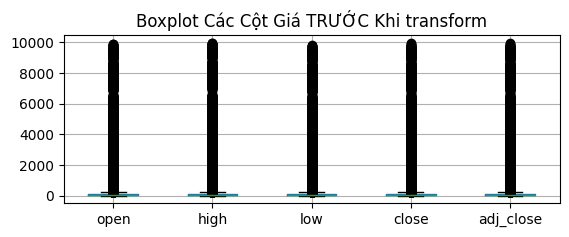

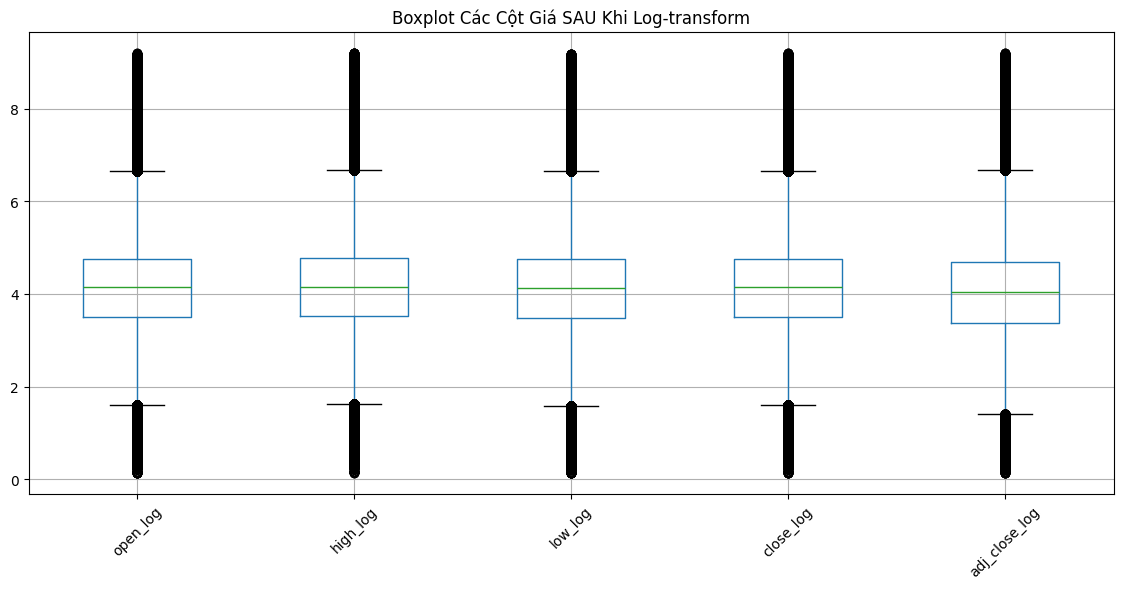

In [12]:

price_cols = ["open", "high", "low", "close", "adj_close"]

for col in price_cols:
    df[col + "_log"] = np.log1p(df[col])
plt.subplot(2, 1, 1)
df[price_cols].boxplot()
plt.title("Boxplot Các Cột Giá TRƯỚC Khi transform")
plt.grid(True)


plt.figure(figsize=(14, 6))
df[[c + "_log" for c in price_cols]].boxplot()
plt.title("Boxplot Các Cột Giá SAU Khi Log-transform")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

4.WINSORIZE CHO VOLUME

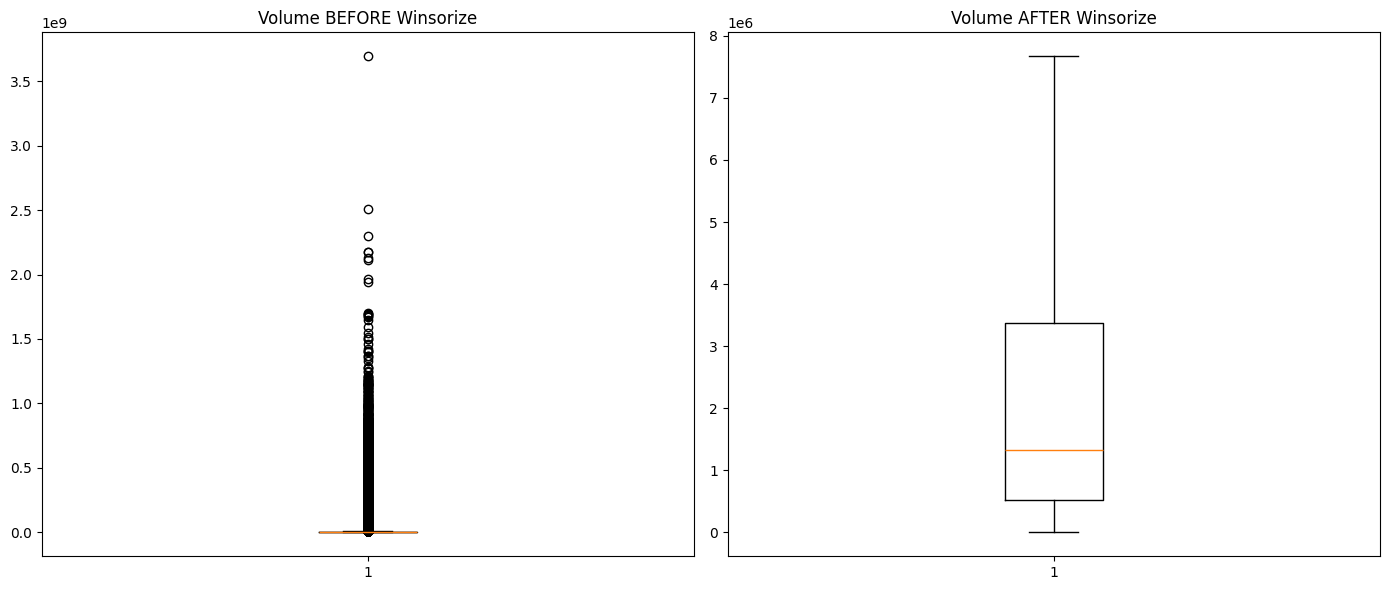

In [13]:
volume = df["volume"]

Q1 = volume.quantile(0.25)
Q3 = volume.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df["volume_winsor"] = volume.clip(lower, upper)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.boxplot(volume)
plt.title("Volume BEFORE Winsorize")

plt.subplot(1, 2, 2)
plt.boxplot(df["volume_winsor"])
plt.title("Volume AFTER Winsorize")

plt.tight_layout()
plt.show()

Save Data_fix_clean

In [14]:
clean_cols = [
    "ts", "symbol",
    "open_log", "high_log", "low_log", "close_log", "adj_close_log",
    "volume_winsor"
]

df_clean = df[clean_cols]
df_clean.to_csv("data_fix_clean.csv", index=False)
